# DS605 - Lab Assignment 1

## Book Scraping from books to scrape site

**Name:** Palak Ganatra  
**Student ID:** 202618042  

**Website:** https://books.toscrape.com/

This notebook demonstrates:

- Web Scraping using Scrapy
- Data Preprocessing using Pandas
- Feature Engineering
- Data Visualization
- Word Cloud Generation
- Insights

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

In [11]:
df = pd.read_csv("books_cleaned.csv")
df.head()

,title,category,price,availability,rating,description,upc,reviews,url,stock,description_word_count,price_category,recommended
0,It's Only the Himalayas,Travel,45.17,In stock (19 available)\n \n\n \n \n ...,2,"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,0,https://books.toscrape.com/catalogue/its-only-...,19,230,Expensive,False
1,Libertarianism for Beginners,Politics,51.33,In stock (19 available)\n \n\n \n \n ...,2,Libertarianism isn't about winning elections; ...,a18a4f574854aced,0,https://books.toscrape.com/catalogue/libertari...,19,195,Expensive,False
2,Mesaerion: The Best Science Fiction Stories 18...,Science Fiction,37.59,In stock (19 available)\n \n\n \n \n ...,1,"Andrew Barger, award-winning author and engine...",e30f54cea9b38190,0,https://books.toscrape.com/catalogue/mesaerion...,19,283,Medium,False
3,Olio,Poetry,23.88,In stock (19 available)\n \n\n \n \n ...,1,"Part fact, part fiction, Tyehimba Jess's much ...",feb7cc7701ecf901,0,https://books.toscrape.com/catalogue/olio_984/...,19,249,Medium,False
4,Our Band Could Be Your Life: Scenes from the A...,Music,57.25,In stock (19 available)\n \n\n \n \n ...,3,This is the never-before-told story of the mus...,deda3e61b9514b83,0,https://books.toscrape.com/catalogue/our-band-...,19,163,Expensive,False


In [33]:
import scrapy

class BooksSpider(scrapy.Spider):
    name = "books"
    allowed_domains = ["books.toscrape.com"]
    start_urls = ["https://books.toscrape.com/"]
    def parse(self, response):
        books = response.css("article.product_pod")

        for book in books:
            book_url = book.css("h3 a::attr(href)").get()
            yield response.follow(book_url, callback=self.parse_book)

        next_page = response.css("li.next a::attr(href)").get()
        if next_page:
            yield response.follow(next_page, callback=self.parse)

    def parse_book(self, response):
        yield {
            "title": response.css(".product_main h1::text").get(),
            "category": response.css("ul.breadcrumb li:nth-child(3) a::text").get(),
            "price": response.css(".price_color::text").get(),
            "availability": "".join(response.css(".availability::text").getall()).strip(),
            "rating": response.css("p.star-rating::attr(class)").get(),
            "description": response.css("#product_description + p::text").get(),
            "upc": response.css("table tr:nth-child(1) td::text").get(),
            "reviews": response.css("table tr:nth-child(7) td::text").get(),
            "url": response.url,
        }

In [30]:
import pandas as pd

df = pd.read_csv("books.csv", encoding="utf-8")

# Remove unwanted characters from price
df["price"] = (
    df["price"]
    .str.replace("Â£", "", regex=False)
    .str.replace("£", "", regex=False)
    .astype(float)
)

rating_map = {
    "One":1,
    "Two":2,
    "Three":3,
    "Four":4,
    "Five":5
}

df["rating"] = (
    df["rating"]
    .str.replace("star-rating ", "", regex=False)
    .map(rating_map)
)

df["stock"] = df["availability"].str.extract(r"(\d+)").astype(int)

df.drop_duplicates(subset="upc", inplace=True)

df["title"] = df["title"].str.strip()

df["description"] = df["description"].str.strip()

df["description_word_count"] = df["description"].apply(lambda x: len(str(x).split()))

df["price_category"] = pd.cut(
    df["price"],
    bins=[0,20,40,60,100],
    labels=["Cheap","Medium","Expensive","Premium"]
)

df["recommended"] = (df["rating"] >= 4) & (df["stock"] > 0)

df.to_csv("books_cleaned.csv", index=False)

print("Cleaning Completed Successfully!")

Cleaning Completed Successfully!


## Data Visualization

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Read cleaned data
df = pd.read_csv("books_cleaned.csv")

# -----------------------------
# 1. Rating Distribution
# -----------------------------
plt.figure(figsize=(6,4))
df["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.tight_layout()
plt.savefig("rating_distribution.png")
plt.close()

# -----------------------------
# 2. Price Distribution
# -----------------------------
plt.figure(figsize=(6,4))
df["price"].plot(kind="hist", bins=15)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.tight_layout()
plt.savefig("price_distribution.png")
plt.close()

# -----------------------------
# 3. Top 10 Categories
# -----------------------------
plt.figure(figsize=(8,5))
df["category"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Book Categories")
plt.tight_layout()
plt.savefig("top_categories.png")
plt.close()

# -----------------------------
# 4. Price vs Rating
# -----------------------------
plt.figure(figsize=(6,4))
plt.scatter(df["rating"], df["price"])
plt.title("Price vs Rating")
plt.xlabel("Rating")
plt.ylabel("Price")
plt.tight_layout()
plt.savefig("price_vs_rating.png")
plt.close()

# -----------------------------
# Word Cloud
# -----------------------------
text = " ".join(df["description"].astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout()
plt.savefig("wordcloud.png")
plt.close()

print("All graphs created successfully!")

All graphs created successfully!


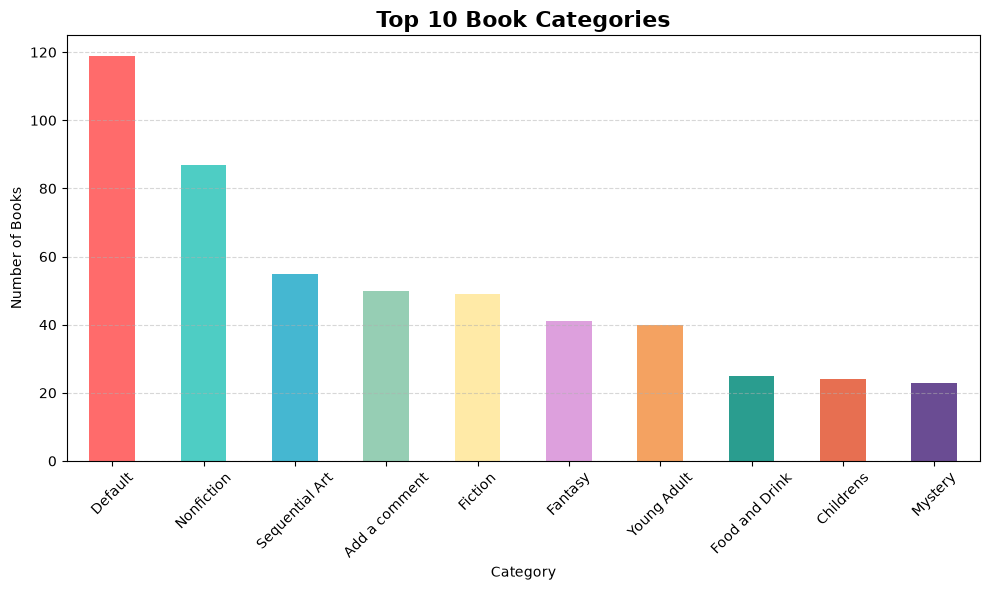

In [17]:
# Bar Chart - Top 10 Categories

plt.figure(figsize=(10,6))
df["category"].value_counts().head(10).plot(
    kind="bar",
    color=["#FF6B6B","#4ECDC4","#45B7D1","#96CEB4","#FFEAA7",
           "#DDA0DD","#F4A261","#2A9D8F","#E76F51","#6A4C93"]
)

plt.title("Top 10 Book Categories", fontsize=16, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Number of Books")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Above given bar grapgh represents top 10 categories for book genre  
We can clearly interpret out of it that most books are of default genre  
Then comes Non-fiction genre with pretty large number of books   
We can see sequential art has very less books comapring to non-fiction and default  
Genres like fantasy and young adult have almost same count of books  
Then come the least count of books for genre like fooad and drink, childrens, mystery

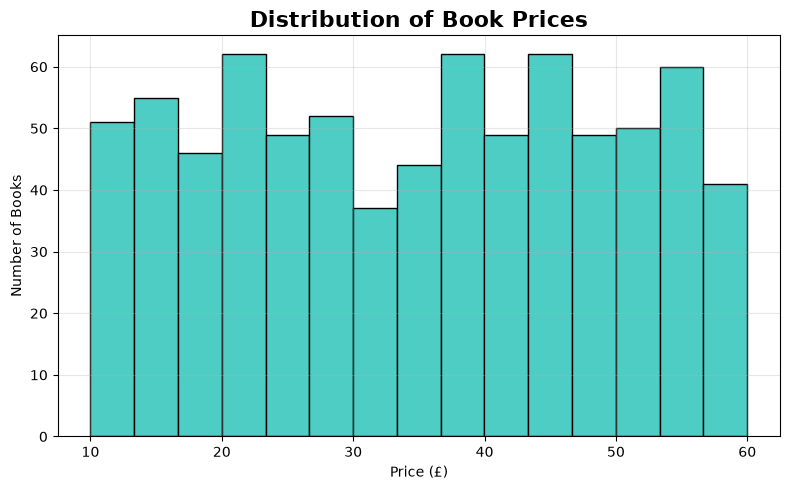

In [18]:
# Price Distribution

plt.figure(figsize=(8,5))
plt.hist(
    df["price"],
    bins=15,
    edgecolor="black",
    color="#4ECDC4"
)

plt.title("Distribution of Book Prices", fontsize=16, fontweight="bold")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Above given bar grapgh represents pricing distribution that is, number of books and pricing for each  
We can see how widespread prices are among all types of books available on site.  
We can conclude cheapest price is almost £35  
Also the highest pricing for books reaches to £60  

From above data we can calculate, 
Average Price: £34.94

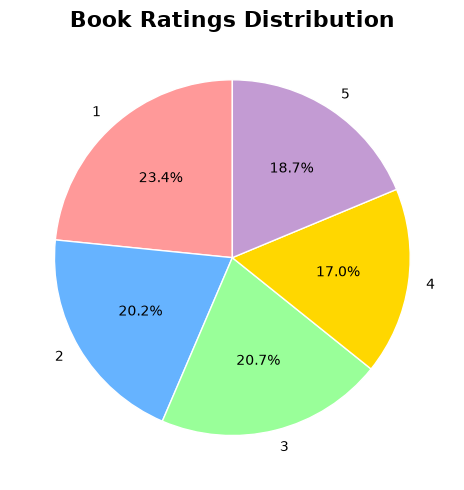

In [20]:
# Ratings Distribution

rating_counts = df["rating"].value_counts().sort_index()

plt.figure(figsize=(7,5))
plt.pie(
    rating_counts,
    labels=rating_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#FF9999","#66B3FF","#99FF99","#FFD700","#C39BD3"],
    wedgeprops={"edgecolor":"white"}
)

plt.title("Book Ratings Distribution", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

Above given pie chart represents book distributions according to its rating  
We can conclude that people have experienced all kind of books in terms of liking that is almost every rating has same number of books available

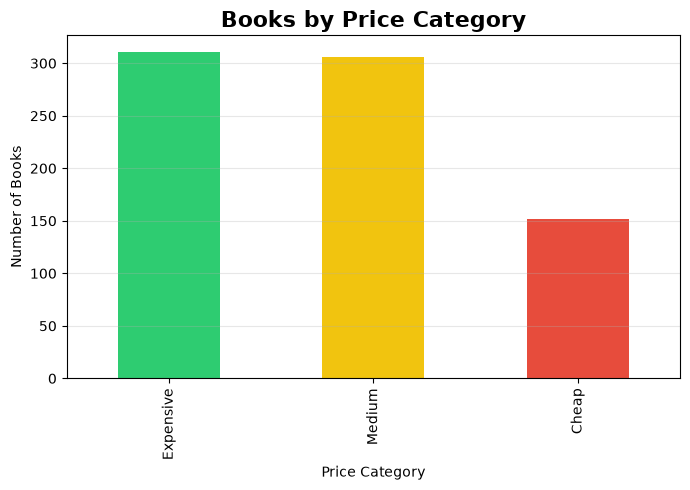

In [21]:
# Price Category Count

plt.figure(figsize=(7,5))

df["price_category"].value_counts().plot(
    kind="bar",
    color=["#2ECC71","#F1C40F","#E74C3C"]
)

plt.title("Books by Price Category", fontsize=16, fontweight="bold")
plt.xlabel("Price Category")
plt.ylabel("Number of Books")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Above given bar graph represents in which category does books fall according to price  
We can clearly conclude that most of books fall under expensive or medium pricing  which may lead to compromising cutomers in long term  
Books falling under medium range or cheap range should also be made available 

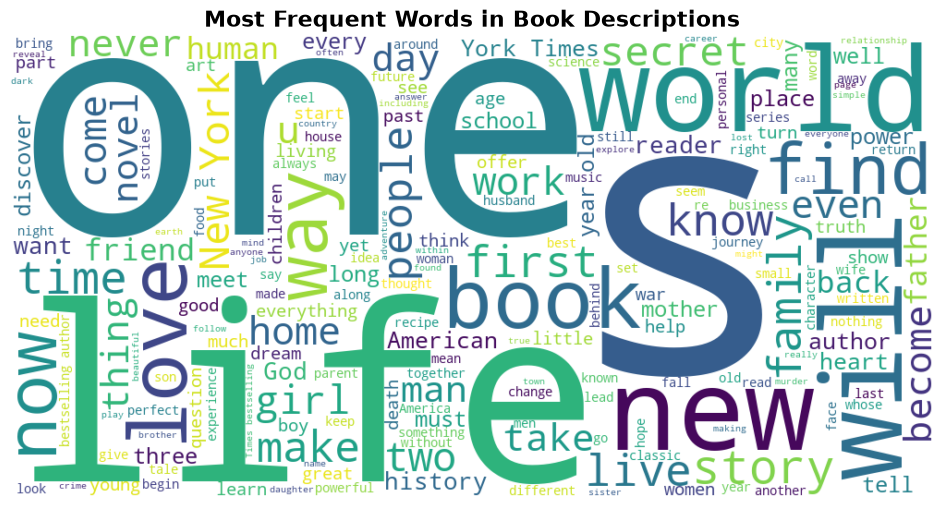

In [23]:
text = " ".join(df["description"].astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    colormap="viridis"
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in Book Descriptions",
          fontsize=16,
          fontweight="bold")
plt.show()

Above given analysis is about most frequesnt words appeared in book descriptions.  
Its analysed using world cloud,  
which basically is finding most frequent words in description  
all the words appears in different size, which is decided as per frequency of thier appearance.  


In [15]:
# Insights about the dataset

print("=" * 50)
print("BOOKS DATASET INSIGHTS")
print("=" * 50)

# Total books
print(f"\n Total Books: {len(df)}")

# Total categories
print(f" Total Categories: {df['category'].nunique()}")

# Average price
print(f" Average Price: £{df['price'].mean():.2f}")

# Highest priced book
highest = df.loc[df['price'].idxmax()]
print("\n Most Expensive Book:")
print(f"Title : {highest['title']}")
print(f"Price : £{highest['price']:.2f}")

# Lowest priced book
lowest = df.loc[df['price'].idxmin()]
print("\n Cheapest Book:")
print(f"Title : {lowest['title']}")
print(f"Price : £{lowest['price']:.2f}")

# Average rating
print(f"\n Average Rating: {df['rating'].mean():.2f}")

# Top 5 categories
print("\n Top 5 Categories:")
print(df['category'].value_counts().head())

# Percentage of recommended books (if column exists)
if 'recommended' in df.columns:
    percent = (df['recommended'].sum() / len(df)) * 100
    print(f"\n Recommended Books: {percent:.2f}%")

BOOKS DATASET INSIGHTS

 Total Books: 769
 Total Categories: 48
 Average Price: £34.94

 Most Expensive Book:
Title : The Perfect Play (Play by Play #1)
Price : £59.99

 Cheapest Book:
Title : An Abundance of Katherines
Price : £10.00

 Average Rating: 2.88

 Top 5 Categories:
category
Default           119
Nonfiction         87
Sequential Art     55
Add a comment      50
Fiction            49
Name: count, dtype: int64

 Recommended Books: 35.76%


# Conclusion

From the above analysis performed we can conclude:

-Most Expensive book is: The Perfect Play  
-Most Cheapest book is: An Abundance of Katherines  
-Total Categories: 48  
-Average Price: £34.94  


Performed book scraping from bookstoscrape website,
I acquired knowledge about what process is used behind searching or analysing on any basic commercial sites,
Analyzed the dataset to find useful information like the average book price, highest and lowest priced books, average rating, and the categories with the most books.
It helped me understand actual implementation of this some terminologies i never came acroos before
Terminologies are: web scraping, data cleaning, analysis, and visualization.